In [1]:
import rasterio
import geopandas as gp
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import random
import csv
from shapely.geometry import Polygon, Point, box
from shapely.ops import unary_union
from geopy.distance import geodesic
import cartopy.crs as ccrs
import numpy as np
from pyproj import Geod
import geopandas as gpd

random.seed(10103)

def compute_polygon_area_km2(polygon):
    """Compute geodesic area of a shapely Polygon in square kilometers.
    The polygon must use (lon, lat) coordinate order (x=longitude, y=latitude).
    """
    #
    geod = Geod(ellps="WGS84")
    # Extract exterior coordinates (lon, lat)
    coords = list(polygon.exterior.coords)
    if len(coords) < 3:
        return 0.0
    if np.array(coords).shape[1]==2:
        lons, lats = zip(*coords)
    elif np.array(coords).shape[1]==3:
        lons, lats,Z = zip(*coords)
    #lons, lats = zip(*coords)
    area, _ = geod.polygon_area_perimeter(lons, lats)
    #
    return abs(area) / 1e6

def grid_points_in_polygon_latlon(polygon_latlon, spacing_km=2, random_km=0.25):
    """Generate a rectangular grid (spacing in km) over the bounding box of a polygon
    provided in (lat, lon) coordinate order, and return the subset of grid points that
    lie inside the original polygon. Add a random perturbation to the points.

    Args:
        polygon_latlon: iterable of (lat, lon) tuples representing the polygon vertices,
                        or a shapely Polygon (assumed to use (lon, lat) order).
        spacing_km: spacing between grid points in kilometers (default 2 km).

    Returns:
        list of (lat, lon) tuples for points inside the polygon.
    """
    #from shapely.geometry import Point, Polygon as ShapelyPolygon

    # Accept either a shapely Polygon (assumed lon,lat) or iterable of (lat, lon)
    if hasattr(polygon_latlon, "exterior"):
        poly = polygon_latlon
        coords = list(poly.exterior.coords)
        if not coords:
            return []
        if np.array(coords).shape[1]==2:
            lons, lats = zip(*coords)
        elif np.array(coords).shape[1]==3:
            lons, lats,Z = zip(*coords)
        min_lat, max_lat = min(lats), max(lats)
        min_lon, max_lon = min(lons), max(lons)
    else:
        pts = list(polygon_latlon)
        if not pts:
            return []
        lats = [p[0] for p in pts]
        lons = [p[1] for p in pts]
        min_lat, max_lat = min(lats), max(lats)
        min_lon, max_lon = min(lons), max(lons)
        poly = ShapelyPolygon([(lon, lat) for lat, lon in pts])

    center_lat = (min_lat + max_lat) / 2.0
    lat_rad    = np.radians(center_lat)

    # Approximate meters per degree latitude/longitude at center latitude using a series expansion
    meters_per_deg_lat = 111132.92 - 559.82 * np.cos(2 * lat_rad) + 1.175 * np.cos(4 * lat_rad) - 0.0023 * np.cos(6 * lat_rad)
    meters_per_deg_lon = 111412.84 * np.cos(lat_rad) - 93.5 * np.cos(3 * lat_rad) + 0.118 * np.cos(5 * lat_rad)
    if meters_per_deg_lon == 0:
        meters_per_deg_lon = 111320.0 * np.cos(lat_rad)

    deg_lat_step = (spacing_km * 1000.0) / meters_per_deg_lat
    deg_lon_step = (spacing_km * 1000.0) / meters_per_deg_lon

    points = []
    lat = min_lat
    # iterate rows
    while lat <= max_lat:
        lon = min_lon
        while lon <= max_lon:
            deg_lat_rstep = (random.uniform(-random_km,random_km) * 1000.0) / meters_per_deg_lat
            deg_lon_rstep = (random.uniform(-random_km,random_km) * 1000.0) / meters_per_deg_lon
            pt_r = Point(lon + deg_lon_rstep, lat + deg_lat_rstep) #point with a random perturbation
            pt   = Point(lon, lat) #original point
            if poly.contains(pt_r) or poly.touches(pt_r):
                points.append((lon + deg_lon_rstep, lat + deg_lat_rstep))
            elif poly.contains(pt) or poly.touches(pt):
                points.append((lon, lat))
            lon += deg_lon_step
        lat += deg_lat_step

    return points


# Function to generate random points inside polygon with min distance
def generate_points(poly, num_points=100, min_distance_km=1, max_attempts=200):
    points = []
    # shapely.bounds returns (minx, miny, maxx, maxy) == (min_lon, min_lat, max_lon, max_lat)
    min_lon, min_lat, max_lon, max_lat = poly.bounds
    #
    attempts = 0
    while len(points) < num_points and attempts < max_attempts:
        attempts += 1
        lat = random.uniform(min_lat, max_lat)
        lon = random.uniform(min_lon, max_lon)
        p = Point(lon, lat)

        if poly.contains(p):
            # Check distance to all existing points
            if all(geodesic((lat, lon), (p2[1], p2[0])).km >= min_distance_km for p2 in points):
                points.append((lon, lat))

    if len(points) < num_points:
        # reduce distance and have another go
        min_distance_km=0.9*min_distance_km
        attempts = 0
        while len(points) < num_points and attempts < max_attempts:
            attempts += 1
            lat = random.uniform(min_lat, max_lat)
            lon = random.uniform(min_lon, max_lon)
            p = Point(lon, lat)

            if poly.contains(p):
                # Check distance to all existing points
                if all(geodesic((lat, lon), (p2[1], p2[0])).km >= min_distance_km for p2 in points):
                    points.append((lon, lat))
    #
    if len(points) < num_points:
        raise RuntimeError(f"Could only place {len(points)} points after {attempts} attempts; increase area or lower min distance.")

    return points

def generate_nturbines(STATUS, N_TURBINES, geometry, POWER_MW, AREA_SQKM,emod_nturbs,emod_polygon,emod_power,emod_area):
    if ((STATUS in ['Production']) and False): #let's not consider active turbines, we get them from the other dataset
        #when in production, we trust the N_turbines
        emod_nturbs.append(N_TURBINES)
        emod_polygon.append(geometry)
        emod_power.append(N_TURBINES*15.0)
        emod_area.append(AREA_SQKM)
    elif (POWER_MW==0 and int(AREA_SQKM/16.0)>0) or (int(AREA_SQKM/16.0) < int(POWER_MW/15.0)):
        # if power is not available, we estimate by area
        emod_nturbs.append(int(AREA_SQKM/16.0))
        emod_polygon.append(geometry)
        emod_power.append(int(AREA_SQKM/16.0)*15.0)
        emod_area.append(AREA_SQKM)
    elif int(POWER_MW/15.0)>0:
        #otherwise, we will just use the total power to estimate the number
        emod_nturbs.append(int(POWER_MW/15.0))
        emod_polygon.append(geometry)
        emod_power.append(int(POWER_MW/15)*15.0)
        emod_area.append(AREA_SQKM)
    #
    return emod_nturbs, emod_polygon, emod_power


#function to get x and y coordinates of all wind turbines
def windfarm(P_t,P,D,latitude,longitude,latituderef=59.35,longituderef=20,r=6362e3):
    # 
    d=7*D
    n=np.ceil(P_t/P)
    dim=int(np.floor(np.sqrt(n))) #dimension of the square
    diff=n-dim**2 #remaining
    #turbines placement (square)
    #creating a dim*dim grid
    x0=np.arange(-dim*d/2,dim*d/2,d)
    y0=np.arange(-dim*d/2,dim*d/2,d)
    X0,Y0=np.meshgrid(x0,y0)
    #
    #getting coordinates of each point
    wt_x=np.ravel(X0)
    wt_y=np.ravel(Y0)
    #condition to add remaining turbines, if dim**2 (number of turbines in the square) is not equal to n
    if diff!=0:
    #coordinates of remaining turbines, added in a last row
        if diff<=dim:
            ysup=np.linspace(-dim*d/2,d*(dim/2-1),int(diff))
            xsup=np.ones(len(ysup))*((dim*d/2))
            #coordinates of all of turbines
            wt_x=np.concatenate([wt_x,xsup])
            wt_y=np.concatenate([wt_y,ysup])
        else:
            xsup0=np.arange(-dim*d/2,dim*d/2,d)
            ysup0=np.ones(len(xsup0))*((dim*d/2))

            ysup1=np.linspace(-dim*d/2,ysup0[0],int(diff-dim))
            xsup1=np.ones(len(ysup1))*((dim*d/2))

            wt_x=np.concatenate([wt_x,xsup0,xsup1])
            wt_y=np.concatenate([wt_y,ysup0,ysup1])
    #
    # transform coordinates into meters from origin
    wt_x=(wt_x+np.radians(longitude-longituderef)*r*np.cos(np.radians(latitude))).astype(np.float32)
    wt_y=(wt_y+np.radians(latitude-latituderef)*r).astype(np.float32)
    #
    return wt_x,wt_y

In [2]:
##
# we have more detailed polygons for Finland and Estonia, just have to combine them first
#
FinnishNames=['/scratch/project_2010748/OWF_database/Baltic/Finland/Ahvenanmaa.shp',
              '/scratch/project_2010748/OWF_database/Baltic/Finland/Ebba.shp',
              '/scratch/project_2010748/OWF_database/Baltic/Finland/Edith.shp',
              '/scratch/project_2010748/OWF_database/Baltic/Finland/Korsnas.shp',
              '/scratch/project_2010748/OWF_database/Baltic/Finland/Kristiinankaupunki.shp',
              '/scratch/project_2010748/OWF_database/Baltic/Finland/Maanahkiainen.shp',
              '/scratch/project_2010748/OWF_database/Baltic/Finland/Peramerietela.shp',
              '/scratch/project_2010748/OWF_database/Baltic/Finland/Perameripohjoinen.shp',
              '/scratch/project_2010748/OWF_database/Baltic/Finland/Pohjanmaan2050.shp',
              '/scratch/project_2010748/OWF_database/Baltic/Finland/PohjoisPohjanmaan.shp',
              '/scratch/project_2010748/OWF_database/Baltic/Finland/Pooki.shp',
              '/scratch/project_2010748/OWF_database/Baltic/Finland/Roytta.shp',
              '/scratch/project_2010748/OWF_database/Baltic/Finland/Satakunnan2050.shp',
              '/scratch/project_2010748/OWF_database/Baltic/Finland/Seljansuunmatala_ita.shp',
              '/scratch/project_2010748/OWF_database/Baltic/Finland/Seljansuunmatala_lansi.shp',
              '/scratch/project_2010748/OWF_database/Baltic/Finland/Selkameriita.shp',
              '/scratch/project_2010748/OWF_database/Baltic/Finland/Selkamerilansi.shp',
              '/scratch/project_2010748/OWF_database/Baltic/Finland/Tahkoluodon.shp']
FinnishPolygons = []
for fname in FinnishNames:
    FinnishPolygons.append(gp.read_file(fname).to_crs(4326))
#
# LOAD DATA FROM SHAPEFILES
estonia      = gp.read_file('/scratch/project_2010748/OWF_database/Baltic/Estonia/vex2_ttja_hoonest_taotl_mtuulep.shp')
emodnet      = gp.read_file('/scratch/project_2010748/OWF_database/Baltic/EMODnet/EMODnet_HA_Energy_WindFarms_pg_20250825.shp')
#FOR THE NORTH SEA, WE HAVE POINTS DIRECTLY
NorthSea_today        = np.loadtxt('/scratch/project_2010748/OWF_database/turbine_locations_harmonie_offshore_only.tab',skiprows=1)
NorthSea2030_points   = gp.read_file('/scratch/project_2010748/OWF_database/NorthSea_CritchleyBuckingham/North_Sea_OWF_2030_turbines.shp')
NorthSea2050_polygons = gp.read_file('/scratch/project_2010748/OWF_database/NorthSea_WaldmanEtAl/OSW_zones.shp')
NorthSea2050_points   = gp.read_file('/scratch/project_2010748/OWF_database/NorthSea_WaldmanEtAl/turbine_locations.shp')
#
# whether to use the actual positions for the existing North Sea OWFs or to use the same method
# of randomly distributing them within polygons for all of them (e.g. assuming that turbines will be upgraded)
NorthSea2050_orig_loc = True 
#convert to lat lon
emodnet_new = emodnet.to_crs(4326)
estonia_new = estonia.to_crs(4326)
#
Baltic_countries=['Denmark','Germany','Poland','Sweden','Finland','Estonia','Lithuania','Latvia']
emod_country = []
emod_polygon = []
emod_power   = []
emod_nturbs  = []
emod_area    = []
Baltic_turbine_loc  = []
c=0
# FIRST WE DEAL WITH THE BALTIC TURBINES
#
# THIS LEADS INTO ~13 700 TURBINES WITH 200 GW INSTALLED
# CAPACITY ASSUMING 15 MW TURBINES
for j,country in enumerate(Baltic_countries): 
    # loop over countries of interest
    if (country in list(emodnet_new.COUNTRY)) or (country in ['Estonia']):
        print(country)
        # merge overlapping polygons
        if (country in ['Estonia']):
            union = unary_union(estonia_new.geometry)
        elif (country in ['Finland']):
            Finnishgeoms=[]
            for p,poly in enumerate(FinnishPolygons):
                if poly.geometry.geom_type[0] in ['MultiPolygon']:
                    Finnishgeoms.extend(list(unary_union(poly.geometry).geoms))
                else:
                    Finnishgeoms.append(poly.geometry[0])
            #
            union = unary_union(Finnishgeoms)
        else:
            union = unary_union(emodnet_new.geometry[np.where(np.logical_and(emodnet_new.COUNTRY==country, emodnet_new.STATUS!='Dismantled'))[0]])
        if union.geom_type in ['MultiPolygon']:
            country_polygons = list(union.geoms)
        else:
            country_polygons = [union]
        # save polygon
        #
        for polygon_latlon in country_polygons:
            min_lon, min_lat, max_lon, max_lat = polygon_latlon.bounds
            if min_lon>9: #only Baltic Sea
                points      = grid_points_in_polygon_latlon(polygon_latlon, spacing_km=2, random_km=0.25)
                emod_polygon.append(polygon_latlon) #polygon
                Baltic_turbine_loc.extend(points) #lon, lat points, just one long list for all turbines
                emod_area.append(compute_polygon_area_km2(polygon_latlon)) #area per polygon
                emod_nturbs.append(len(points)) #number of turbines per polygon
                emod_country.append(country)    #country per polygon
#
Baltic_turbine_loc = np.array(Baltic_turbine_loc)

Denmark
Germany
Poland
Sweden
Finland
Estonia
Lithuania
Latvia


In [8]:
# combine list of countries, polygon areas and number of turbines to geodataframe with geometry from polygons
windfarms = gpd.GeoDataFrame({'Country': emod_country, 'Area_km2': emod_area, 'N_turbines': emod_nturbs},geometry=emod_polygon,crs=emodnet.crs)

In [9]:
windfarms

,Country,Area_km2,N_turbines,geometry
0,Denmark,23.045484,4,"POLYGON ((11.74786 54.56324, 11.76105 54.56189..."
1,Denmark,31.725391,8,"POLYGON ((11.53456 54.57073, 11.54207 54.5693,..."
2,Denmark,24.541017,6,"POLYGON ((11.1111 55.07773, 11.11484 55.07661,..."
3,Denmark,54.214044,13,"POLYGON ((9.92226 55.11239, 9.82484 55.07892, ..."
4,Denmark,37.312777,8,"POLYGON ((9.79019 55.23593, 9.81584 55.21565, ..."
...,...,...,...,...
132,Latvia,100.530334,23,"POLYGON ((20.68585 56.04557, 20.66619 56.04569..."
133,Latvia,407.605921,99,"POLYGON ((20.43791 56.0469, 20.43591 56.04691,..."
134,Latvia,348.956488,87,"POLYGON ((20.86371 56.83332, 20.81732 56.77299..."
135,Latvia,607.661561,153,"POLYGON ((20.95695 56.96494, 20.95458 56.96488..."


In [23]:
# extract only Bothnian Sea
lat1 = 60.19368
lat2 = 63.51992
lon1 = 17.00320
lon2 = 21.90664
bbox = box(lon1, lat1, lon2, lat2)
windfarms_BS = windfarms[windfarms.intersects(bbox)].copy()

<Axes: >

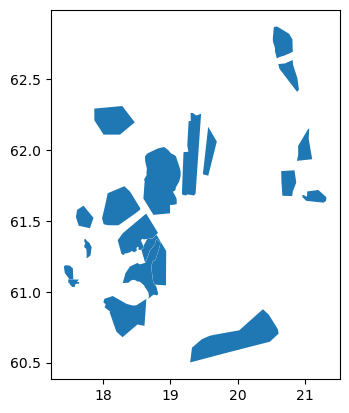

In [24]:
windfarms_BS.plot()

In [25]:
windfarms_BS.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
windfarms_BS.loc[:,'FarmID'] = list(range(1,len(windfarms_BS)+1))

In [29]:
windfarms_BS.columns
columns = ['FarmID', 'Country', 'Area_km2', 'N_turbines', 'geometry']

In [30]:
# save to shapfile
windfarms_BS[columns].to_file('Wind_farms_Bothnian_Sea.shp')